In [ ]:
import pandas as pd
from pathlib import Path

# Set up local paths relative to notebook location
PROJECT_ROOT = Path("..").resolve()
RAW_DATA = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

# Get all CSV files sorted by name
files = sorted(RAW_DATA.glob("*.csv"))

In [4]:
summary = []
for file in files:

    df = pd.read_csv(file)

    summary.append({
        "dataset": file.name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_values": df.isnull().sum().sum(),
        "duplicates": df.duplicated().sum()
    })
    summary_df = pd.DataFrame(summary)

summary_df

,dataset,rows,columns,missing_values,duplicates
0,01_fund_master.csv,40,15,0,0
1,02_nav_history.csv,46000,3,0,0
2,03_aum_by_fund_house.csv,90,5,0,0
3,04_monthly_sip_inflows.csv,48,6,12,0
4,05_category_inflows.csv,144,3,0,0
5,06_industry_folio_count.csv,21,6,0,0
6,07_scheme_performance.csv,40,19,0,0
7,08_investor_transactions.csv,32778,13,0,0
8,09_portfolio_holdings.csv,322,8,0,0
9,10_benchmark_indices.csv,8050,3,0,0


In [5]:
summary_df.to_csv(
    f"{PROCESSED_DATA}/dataset_summary.csv",
    index=False
)
print("done exporting")

done exporting


Fund Master Dataset Columns: Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')
Fund Master Dataset Rows: 40
Unique Fund Houses: 10
Fund House Schemes: fund_house
SBI Mutual Fund             5
HDFC Mutual Fund            5
ICICI Prudential MF         5
Nippon India MF             5
Kotak Mahindra MF           4
Axis Mutual Fund            4
Aditya Birla Sun Life MF    3
UTI Mutual Fund             3
Mirae Asset MF              3
DSP Mutual Fund             3
Name: count, dtype: int64
Category Available: <StringArray>
['Equity', 'Debt']
Length: 2, dtype: str
Count of Categories: category
Equity    34
Debt       6
Name: count, dtype: int64
Sub Category Available: <StringArray>
[      'Large Cap',       'Small Cap',            'Gilt',         'Mid Cap',
  '

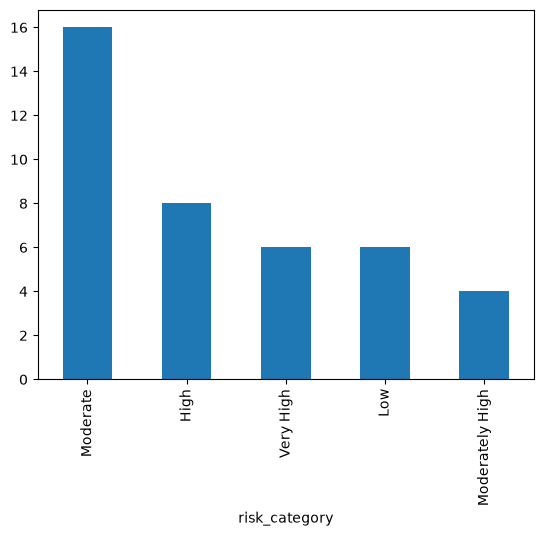

In [11]:
#Understand Fund Master Dataset
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)
print("Fund Master Dataset Columns:", fund_master.columns)
print("Fund Master Dataset Rows:", fund_master.shape[0])
print("Unique Fund Houses:", fund_master['fund_house'].nunique())
print("Fund House Schemes:",fund_master["fund_house"].value_counts())
fund_master["fund_house"].value_counts().plot(kind="bar")
print("Category Available:",fund_master["category"].unique())
print(f"Count of Categories: {fund_master['category'].value_counts()}")
print(f"Sub Category Available: {fund_master['sub_category'].unique()}")
print(f"Count of Sub Categories: {fund_master['sub_category'].value_counts()}")
print(f"Risk Distribution: {fund_master['risk_category'].value_counts()}")
fund_master["risk_category"].value_counts().plot(kind="bar")
print(f"Average Expense Ratio: {fund_master['expense_ratio_pct'].mean()}")
print(f"Top Expensive Fund: {fund_master.nlargest(5,'expense_ratio_pct')}")
print(f"Loewest Expense Fund: {fund_master.nsmallest(5,'expense_ratio_pct')}")
print(f"Plans Available: {fund_master['plan'].value_counts()}")


In [12]:
import pandas as pd

# Load datasets
fund_master = pd.read_csv(
    f"{RAW_DATA}/01_fund_master.csv"
)

nav_history = pd.read_csv(
    f"{RAW_DATA}/02_nav_history.csv"
)

# Convert to same datatype
fund_master["amfi_code"] = fund_master["amfi_code"].astype(str)
nav_history["amfi_code"] = nav_history["amfi_code"].astype(str)

# Find missing codes
missing_codes = (
    set(fund_master["amfi_code"])
    - set(nav_history["amfi_code"])
)

print("=" * 50)
print("AMFI CODE VALIDATION REPORT")
print("=" * 50)

print(f"Total Fund Master Codes : {fund_master['amfi_code'].nunique()}")
print(f"Total NAV Codes         : {nav_history['amfi_code'].nunique()}")

if len(missing_codes) == 0:
    print("\n✅ SUCCESS: All AMFI codes exist in NAV History")
else:
    print(f"\n❌ Missing Codes Count: {len(missing_codes)}")
    print("Missing Codes:")
    print(sorted(missing_codes))

AMFI CODE VALIDATION REPORT
Total Fund Master Codes : 40
Total NAV Codes         : 40

✅ SUCCESS: All AMFI codes exist in NAV History


In [13]:
report = []

report.append("# Data Quality Report")
report.append("")
report.append(f"Fund Master Unique Codes : {fund_master['amfi_code'].nunique()}")
report.append(f"NAV History Unique Codes : {nav_history['amfi_code'].nunique()}")
report.append("")

if len(missing_codes) == 0:
    report.append("Result: PASS")
    report.append("All AMFI codes found in NAV history.")
else:
    report.append("Result: FAIL")
    report.append(f"Missing Codes Count: {len(missing_codes)}")
    report.append("")
    report.extend(sorted(missing_codes))

with open(
    f"{PROCESSED_DATA}/data_quality_report.md",
    "w",
    encoding="utf-8"
) as f:
    f.write("\n".join(report))

print("✅ data_quality_report.md saved successfully")

✅ data_quality_report.md saved successfully
